In [ ]:
pip install pydub

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import tensorflow as tf
from google.colab import drive
from tqdm import tqdm
import os
import numpy as np

# Audio segment creation
import math
from pydub import AudioSegment

import librosa
import matplotlib.pyplot as plt

ModuleNotFoundError: ignored

In [ ]:
print(tf.__version__)

2.9.2


In [ ]:
import sys
print(sys.version)

3.7.15 (default, Oct 12 2022, 19:14:55) 
[GCC 7.5.0]


In [ ]:
# Connect Google Drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Path to saved model
MODEL_PATH = '/content/drive/MyDrive/prev-experiments/cnn_4/model/mels_cnn_new.h5'

# Sampling rate.
sr = 22050

# Let's make sure all files have the same amount of samples, pick a duration right under 30 seconds.
TOTAL_SAMPLES = 30 * sr

# X amount of slices => X times more training examples.
NUM_SLICES = 10
SAMPLES_PER_SLICE = int(TOTAL_SAMPLES / NUM_SLICES)

# Genres to analyze
genres = ['deep_house', 'tech_house', 'melodic_techno', 'progressive', 'techno_peak_time', 'hard_techno', 'minimal', 'trance']

In [ ]:
model = tf.keras.models.load_model(MODEL_PATH)

In [ ]:
file_path = '/content/drive/MyDrive/prev-experiments/cnn_4/examples/MAJELLO Late at Night Mastered V1.wav'

In [ ]:
mfcc_list = []
y, sr = librosa.load(file_path, sr=sr)
for i in range(0, len(y)//(sr*3)):
  mfcc = librosa.feature.mfcc(y=y[i:i+sr*3], sr=sr, n_mfcc=13)
  mfcc = mfcc.T
  mfcc_list.append(mfcc.tolist())

mfcc_list = np.array(mfcc_list)
mfcc_list = mfcc_list[..., np.newaxis]

In [ ]:
def make_prediction(model, X):
    predictions = model.predict(X)
    predicted_genre = -1
    song_pred = np.zeros(len(genres))
    for prediction_vector in predictions:
      for i in range(len(genres)):
        song_pred[i] += prediction_vector[i]

    return song_pred / np.sum(song_pred)

2/2 [==============================] - 0s 17ms/step


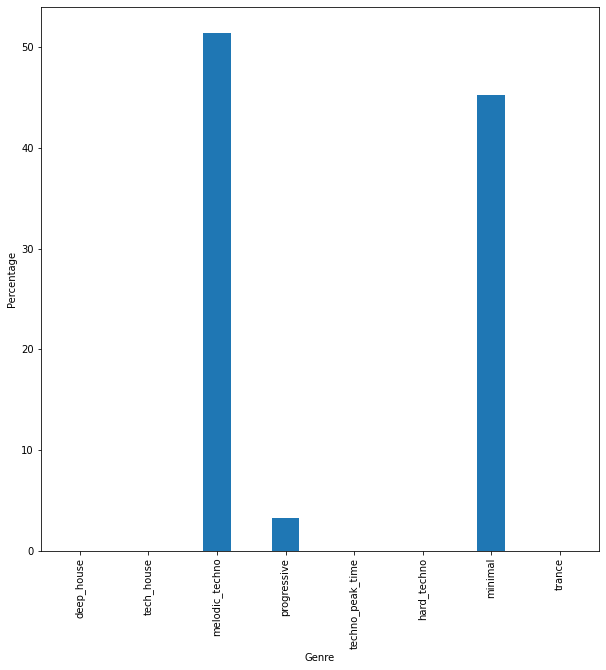

In [ ]:
prediction_vector = make_prediction(model, mfcc_list)
plt.figure(figsize=(10,10))
plt.bar(genres, prediction_vector * 100, width = 0.4)
plt.xlabel("Genre")
plt.ylabel("Percentage")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
file_path = '/content/drive/MyDrive/prev-experiments/prev_experiments_datasets/deep_house/DAVI - Home (Original Mix) [TRYBESof].aiff'
metadata = audio_metadata.load(file_path)
print(metadata)

UnsupportedFormat: ignored